Import necessary libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gdown
import os

Section 0: Download images

    Definition:
        # gdown is a Python tool to download files from Google Drive via shared links.

    Importance:
        # Automates the data loading process and uses SSL-secure download from Drive.

In [ ]:
left_id = '1qMAQSEE6Hy0d_zJtOgAkg5WKef-3_3r4'
right_id = '10c6QwmEI8jaYjW-OevjfVACNsbw489-G'

gdown.download(f'https://drive.google.com/uc?id={left_id}', 'left.png', quiet=False)
gdown.download(f'https://drive.google.com/uc?id={right_id}', 'right.png', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qMAQSEE6Hy0d_zJtOgAkg5WKef-3_3r4
To: /content/left.png
100%|██████████| 30.5k/30.5k [00:00<00:00, 33.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=10c6QwmEI8jaYjW-OevjfVACNsbw489-G
To: /content/right.png
100%|██████████| 29.5k/29.5k [00:00<00:00, 42.9MB/s]


'right.png'

Section 1: Load stereo images

    Definition:
        # Stereo images are two views (left and right) captured simultaneously by cameras placed side-by-side.
        
    Importance:
        # Input to all stereo vision tasks such as disparity and depth estimation.

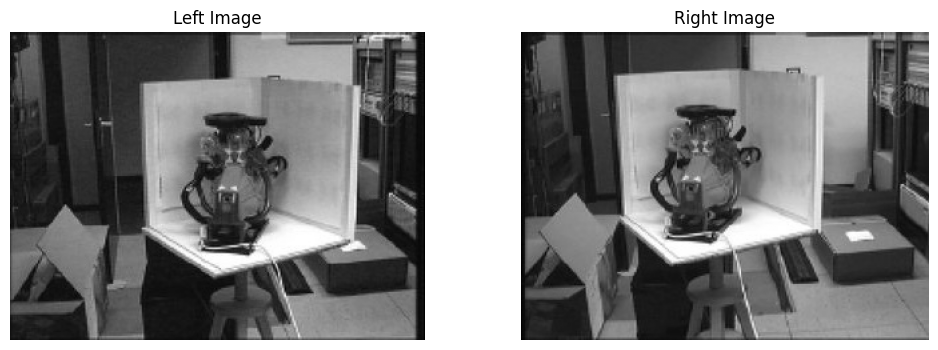

In [ ]:
left_img = cv2.imread("left.png", cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread("right.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1); plt.title("Left Image"); plt.axis("off")
plt.imshow(left_img, cmap='gray')
plt.subplot(1,2,2); plt.title("Right Image"); plt.axis("off")
plt.imshow(right_img, cmap='gray')
plt.show()

Section 1.5: Resize to match image dimensions

    StereoBM requires both images to have the same resolution

In [ ]:
h = min(left_img.shape[0], right_img.shape[0])
w = min(left_img.shape[1], right_img.shape[1])

left_img = cv2.resize(left_img, (w, h))
right_img = cv2.resize(right_img, (w, h))

Section 2: Compute disparity map

    Definition:
        # Disparity (d) is the horizontal shift between corresponding pixels in left and right images.

    Formula:
      disparity = x_left - x_right

    Importance:
        # Disparity encodes relative depth: larger disparity → closer object.

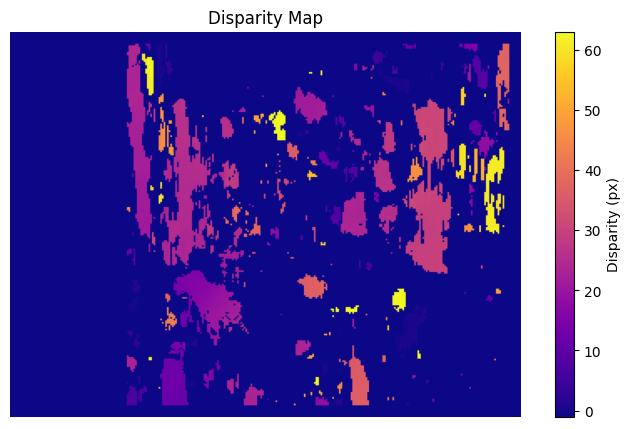

In [ ]:
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)
disp = stereo.compute(left_img, right_img).astype(np.float32) / 16.0

plt.figure(figsize=(9,5))
plt.imshow(disp, cmap='plasma')
plt.colorbar(label="Disparity (px)")
plt.title("Disparity Map")
plt.axis("off")
plt.show()

Section 3: Compute depth map

    Definition:
        # Depth (Z) is real-world distance from the camera.

    Formula:
      Z = (f × B) / d
          where f = focal length (px), B = baseline (m), d = disparity (px)
        # KITTI stereo camera parameters are often used:
        #   f = 721.0 pixels, B = 0.54 meters

    Importance:
        # Converts pixel disparity into physical distance (in meters).

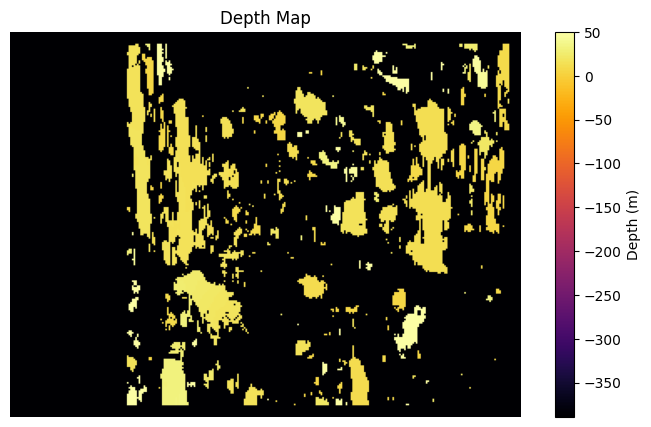

In [ ]:
f, B = 721.0, 0.54
# these parameters are assumed
depth = f * B / (disp + 1e-6) # Add small value to avoid division by zero

# Visualize the depth map
plt.figure(figsize=(9,5))
plt.imshow(depth, cmap='inferno', vmax=50)
plt.colorbar(label="Depth (m)")
plt.title("Depth Map")
plt.axis("off")
plt.show()

Section 4: Visualize epipolar lines

    Definition:
        # In rectified stereo images, corresponding points lie on the same scanline (horizontal line).

    Importance:
        # Validates stereo rectification. Helps visualize geometry of image correspondence.

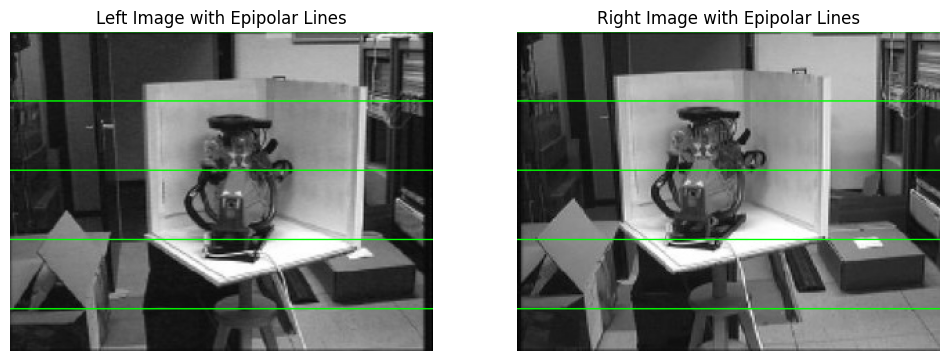

In [ ]:
def add_epilines(img, color=(0,255,0), step=50):
    """
    Draw horizontal epipolar lines across the image.
    Args:
        img: Grayscale image
        color: RGB color of lines
        step: Vertical spacing between lines
    Returns:
        BGR image with epipolar lines overlaid
    """
    h, w = img.shape
    img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for y in range(0, h, step):
        cv2.line(img_c, (0, y), (w, y), color, 1)
    return img_c

# Add epipolar lines to both images
left_epi = add_epilines(left_img)
right_epi = add_epilines(right_img)

# Display
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.title("Left Image with Epipolar Lines"); plt.axis("off")
plt.imshow(left_epi)
plt.subplot(1, 2, 2); plt.title("Right Image with Epipolar Lines"); plt.axis("off")
plt.imshow(right_epi)
plt.show()